In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt 
%matplotlib inline 

**1. Load and Display a Color Image**

shape of the home_rgb image :  (597, 576, 3)


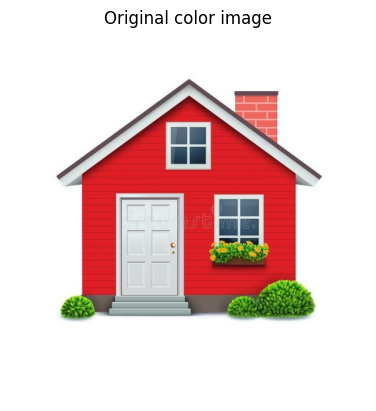

In [2]:
home_bgr = cv2.imread('./data/Home.jpeg')

#Determine the shape of the image 
print('shape of the home_rgb image : ' ,home_bgr.shape)

# Convert the image from BGR to RGB to represent it in correct way using plt 
home_rgb = cv2.cvtColor(home_bgr , cv2.COLOR_BGR2RGB)

#Reprent the image using plt
plt.imshow(home_rgb)
plt.title('Original color image')
plt.axis('off')
plt.show()

**Explain:**

1. What is the shape of the image? (e.g., What line of code is used to display the
iamge shape?)

- the image has a shape of (597, 576, 3) , the image has a rectangle shape which has 597 for number of rows , 576 for number of columns and 3 which mention that we have three channels for every color (because we have a colored image)
  
2. What do the channels represent?

- Every channel represent the intensity of every color from the BGR color system which openCV library use it , the first channel for blue channel , the second for green color and the third channel is for red color , every channel is a 2D array which has values from 0 to 255

**2. Convert to Grayscale**

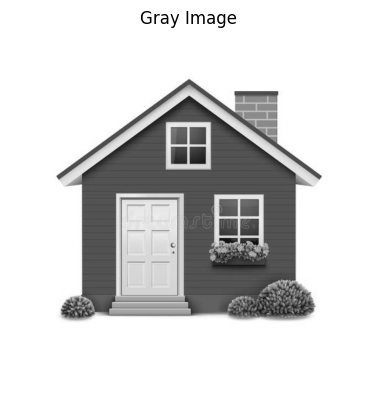

Shape of the home_gray image  (597, 576)


In [3]:
home_gray = cv2.cvtColor(home_rgb , cv2.COLOR_RGB2GRAY)

#Reprent the image using plt
plt.imshow(home_gray , cmap='gray')
plt.title('Gray Image')
plt.axis('off')
plt.show()

#Reprent the shape 
print('Shape of the home_gray image ',home_gray.shape)


**Explain:**

1. What changed compared to the original image?

- I can see that the image converted from color mode which has three channels (image of 3D array) to the gray mode which has one channel (image of 3D array)
  
2. What information is preserved and what is lost?

- after we convert the image to gray mode we still preserved it's structure information , shape and intensity of the image ( because the contrast between dark and light remains) so we still recognize the image boundaries and features .
- but we lost all color information(like color saturation and Hue ) so we can't distinguish objects on image based on it's color .


**3. Noise Reduction (Smoothing)**

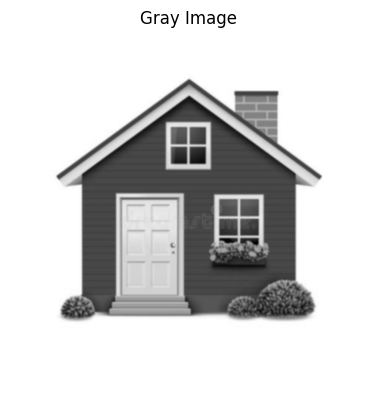

In [4]:
smoothed_home = cv2.GaussianBlur(home_gray,(5,5),0)

#Represent the image using plt
plt.imshow(smoothed_home , cmap='gray')
plt.title('Gray Image')
plt.axis('off')
plt.show()

**Explain:**

1. Why do we apply smoothing before edge detection?

- We apply smoothing to remove noise and unwanted details from the image .
  
2. What visual changes do you observe?

- I see that the image appears slightly blurred , the tiny details like leaves on trees have disappeared but the big parts like the house walls are still easy to see but they look smoother . 

**4. Edge Detection**

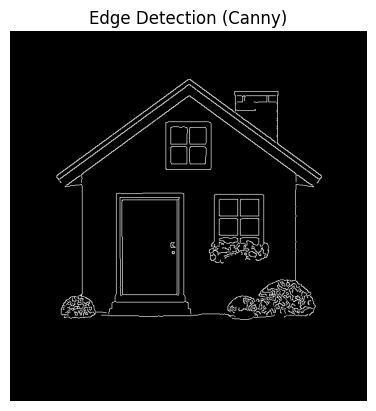

In [5]:
#Using the Canny algorithm for edge detection 
edges = cv2.Canny(smoothed_home, 100, 200)

plt.imshow(edges, cmap='gray')
plt.title('Edge Detection (Canny)')
plt.axis('off')
plt.show()

**Explain:**

1. What do the edges represent?

- The edge represent the areas where there a sharp change in brightness , Boundaries of objects , as in our image it shows the structure of home and it's structure and main feature like roof , windows and doors . 


**5. From Edges to Structure**

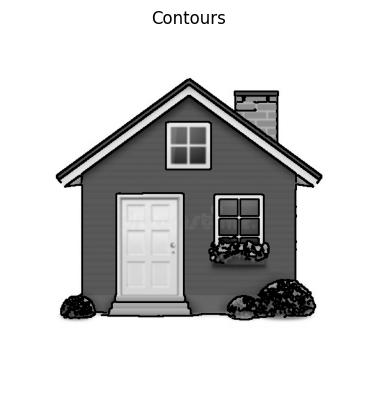

In [6]:

contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)


structured_img = smoothed_home.copy()


cv2.drawContours(structured_img, contours, -1, (0, 255, 0), 2)


plt.imshow(structured_img, cmap='gray')
plt.title('Contours')
plt.axis('off')
plt.show()

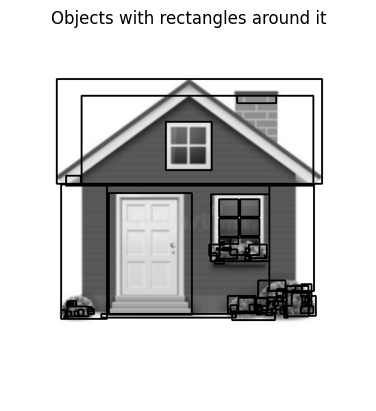

In [7]:
boxed_img = smoothed_home.copy()

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(boxed_img, (x, y), (x+w, y+h), 0, 2 )

plt.imshow(boxed_img, cmap='gray')
plt.title('Objects with rectangles around it')
plt.axis('off')
plt.show()

**Explain:**

1. What information is missing compared to the original image?
   
- we miss the color ( we don't have the RGB values ) , the texture as surface of wall , most of unimportant details have removed to only focused on main objects . 
  
- we lost the lighting and shadows so the 3D depth which creted by light is gone . 
